In [45]:
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm.auto import tqdm


In [41]:
patches_path = '/mnt/data8tb/fire_detection/modis/msg_cm_dataset_patches/'
patches_list = [os.path.join(patches_path, i) for i in os.listdir(patches_path)]

In [ ]:
nan_msg_list = []
nan_modis_list = []
unrecon_list = []
for patch in tqdm(patches_list, desc="Processing patches", unit="file"):
    ds = rioxarray.open_rasterio(patch)
    nan_msg_count = int(np.count_nonzero(np.isnan(ds[:11])))
    total_msg_count = int(ds[:11].size)
    pct_nan = nan_msg_count / total_msg_count
    nan_msg_list.append(pct_nan)

    nan_count =  np.count_nonzero(ds[11] == -1) 
    # get total pixel count
    total_count = int(ds[11].size)
    # check if nan_count is within allowed cutoff
    pct_modis_nan = nan_count / total_count
    nan_modis_list.append(pct_modis_nan)

    cm_da = ds[11]
    nan_count =  np.count_nonzero(cm_da == -1) 
    # get total pixel count
    total_count = int(cm_da.size)
    # check if nan_count is within allowed cutoff
    unrec_nan = nan_count / total_count
    unrecon_list.append(unrec_nan)


Processing patches:   0%|          | 0/189910 [00:00<?, ?file/s]

In [42]:
test = rioxarray.open_rasterio('/mnt/data8tb/fire_detection/modis/msg_cm_dataset_patches/20200601125744_patch_83.tif')

In [44]:
test

<xarray.DataArray (band: 12, y: 32, x: 32)> Size: 98kB
[12288 values with dtype=float64]
Coordinates:
  * band         (band) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * x            (x) float64 256B -3.015 -2.978 -2.942 ... -1.95 -1.913 -1.877
  * y            (y) float64 256B 41.08 41.05 41.01 40.97 ... 40.02 39.98 39.95
    spatial_ref  int64 8B 0
Attributes: (12/22)
    band_names:               ['IR_016', 'IR_039', 'IR_087', 'IR_097', 'IR_10...
    calibration:              radiance
    end_time:                 2020-06-01 13:00:00
    georef_offset_corrected:  true
    modifiers:                []
    modis_image:              MYD35_L2.A2020153.1255.061.2020155201315.tif
    ...                       ...
    wavelength:               1.64 µm (1.5-1.78 µm)
    AREA_OR_POINT:            Area
    _FillValue:               nan
    scale_factor:             1.0
    add_offset:               0.0
    long_name:                Rad

In [31]:
cm = test[11].values
cm = np.clip(cm, 1, 2, out=cm)

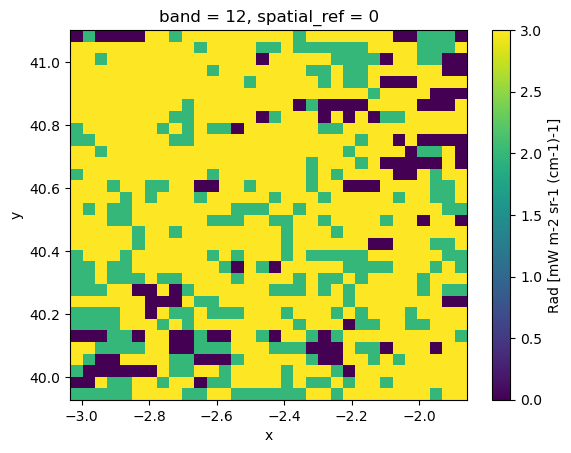

In [36]:
cm_da = test[11]
cm_da = cm_da.where(cm_da != 1)  
cm_da_interp = cm_da.interpolate_na(dim="x", method='nearest', fill_value="extrapolate")
cm_da_interp.plot()

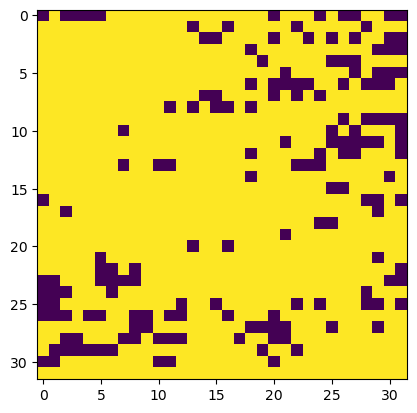

In [26]:
plt.imshow(cm)

In [21]:
np.unique(test[11])


array([0., 1., 2., 3.])

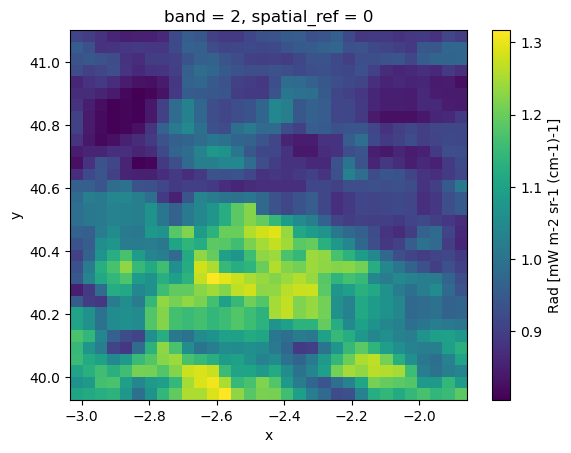

In [22]:
test[1].plot()